# Entity Matching — Run Analysis

Three-layer evaluation for any augmentation run:
1. **Standard metrics** — precision / recall / F1 / confusion matrix
2. **Training set characteristics** — label ratio, similarity distribution, corner cases, attribute coverage
3. **Error analysis** — FP/FN examples categorised by error class

**To reuse**: change only the four variables in the *Configuration* cell below.

## Configuration

In [19]:
DATASET = "wdc-products"      # "wdc-products" | "dblp-scholar"
RUN = "string_aug_cw"       # run name used in evaluate.py
SPLIT = "test"              # "train" | "valid" | "test"
TRAIN_FILE = "train_aug_string"             # filename (no .txt) in data/processed/<dataset>/

## Imports & paths

In [20]:
import gzip
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

ROOT       = Path("../")
RESULTS    = ROOT / "experiments" / "results"
PROCESSED  = ROOT / "data" / "processed" / DATASET
RAW_WDC    = ROOT / "data" / "raw" / "wdc-products"

result_file = RESULTS / f"{RUN}_{DATASET}_{SPLIT}.json"
preds_file  = RESULTS / f"{RUN}_{DATASET}_{SPLIT}_preds.jsonl"
train_file  = PROCESSED / f"{TRAIN_FILE}.txt"
test_file   = PROCESSED / f"{SPLIT}.txt"

print(f"Result JSON : {result_file}  exists={result_file.exists()}")
print(f"Preds JSONL : {preds_file}  exists={preds_file.exists()}")
print(f"Train file  : {train_file}  exists={train_file.exists()}")
print(f"Test file   : {test_file}  exists={test_file.exists()}")

Result JSON : ../experiments/results/string_aug_cw_wdc-products_test.json  exists=True
Preds JSONL : ../experiments/results/string_aug_cw_wdc-products_test_preds.jsonl  exists=True
Train file  : ../data/processed/wdc-products/train_aug_string.txt  exists=True
Test file   : ../data/processed/wdc-products/test.txt  exists=True


## Helper functions

In [21]:
_COL_VAL_RE = re.compile(r'COL\s+\S+\s+VAL\s*')

def load_pairs(path: Path) -> list[tuple[str, str, int]]:
    """Return list of (left, right, label) from a Ditto COL/VAL TSV file."""
    pairs = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) == 3:
                pairs.append((parts[0], parts[1], int(parts[2])))
    return pairs


def value_tokens(col_val_str: str) -> set[str]:
    """Strip COL/VAL markers and return lowercased value token set."""
    text = _COL_VAL_RE.sub(' ', col_val_str)
    return set(text.lower().split())


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)


def pair_sim(left: str, right: str) -> float:
    return jaccard(value_tokens(left), value_tokens(right))


def load_raw_wdc(split: str) -> dict[str, bool]:
    """Return {pair_id: is_hard_negative} from raw WDC gzipped JSONL."""
    gz = RAW_WDC / f"{split}_raw.json.gz"
    result = {}
    if not gz.exists():
        print(f"[warn] {gz} not found — skipping raw WDC corner-case analysis")
        return result
    with gzip.open(gz, "rt", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            result[rec["pair_id"]] = bool(rec.get("is_hard_negative", False))
    return result


def classify_error(left: str, right: str, true_label: int, pred_label: int, sim: float) -> str:
    toks_l = value_tokens(left)
    toks_r = value_tokens(right)
    if len(toks_l) < 6 or len(toks_r) < 6:
        return "noisy/incomplete text"
    if pred_label == 1 and true_label == 0 and sim > 0.5:
        return "high-sim non-match"
    if pred_label == 0 and true_label == 1 and sim < 0.2:
        return "low-sim match"
    return "ambiguous variant"


def truncate(s: str, n: int = 90) -> str:
    vals = _COL_VAL_RE.sub(' ', s).strip()
    return vals[:n] + "…" if len(vals) > n else vals


print("Helpers defined.")

Helpers defined.


---
## Section 1 — Standard Metrics

In [22]:
with open(result_file) as f:
    result = json.load(f)

m = result["metrics"]
cm = result["confusion_matrix"]

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1"],
    "Value": [m["precision"], m["recall"], m["f1"]],
})
metrics_df["Value"] = metrics_df["Value"].map("{:.4f}".format)

print(f"Run: {result['run']}   Dataset: {result['dataset']}   Split: {result['split']}")
print(f"Pairs: {result['n_pairs']}  Matches: {result['n_matches']}  Non-matches: {result['n_non_matches']}")
print()
print(metrics_df.to_string(index=False))

Run: string_aug_cw   Dataset: wdc-products   Split: test
Pairs: 4500  Matches: 500  Non-matches: 4000

   Metric  Value
Precision 0.6506
   Recall 0.7040
       F1 0.6763


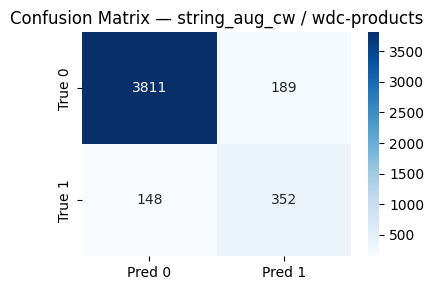

In [23]:
cm_arr = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm_arr, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix — {result['run']} / {result['dataset']}")
plt.tight_layout()
plt.show()

---
## Section 2 — Training Set Characteristics

Analysing: **`TRAIN_FILE`**

In [24]:
train_pairs = load_pairs(train_file)
n_train = len(train_pairs)
n_pos = sum(l for _, _, l in train_pairs)
n_neg = n_train - n_pos

print(f"Training file : {TRAIN_FILE}.txt")
print(f"Total pairs   : {n_train:,}")
print(f"Matches (pos) : {n_pos:,}  ({100*n_pos/n_train:.1f}%)")
print(f"Non-matches   : {n_neg:,}  ({100*n_neg/n_train:.1f}%)")
print(f"Ratio pos:neg : 1:{n_neg/n_pos:.1f}  (target ≈ 1:3)")

Training file : train_aug_string.txt
Total pairs   : 5,000
Matches (pos) : 1,000  (20.0%)
Non-matches   : 4,000  (80.0%)
Ratio pos:neg : 1:4.0  (target ≈ 1:3)


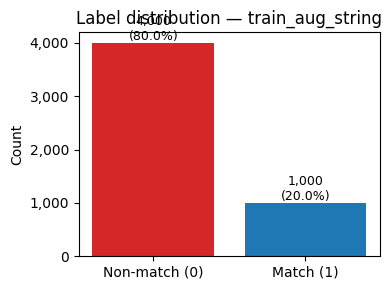

In [25]:
# 2a — Label ratio bar chart
fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(["Non-match (0)", "Match (1)"], [n_neg, n_pos], color=["#d62728", "#1f77b4"])
for bar, val in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:,}\n({100*val/n_train:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title(f"Label distribution — {TRAIN_FILE}")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

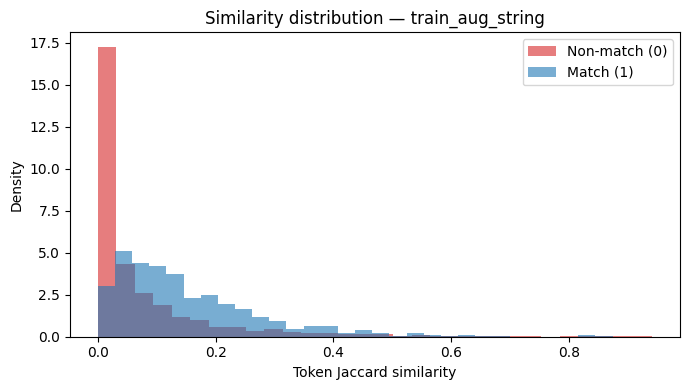

Match    sims — mean: 0.155  median: 0.121
Non-match sims — mean: 0.072  median: 0.023


In [26]:
# 2b — Similarity distribution
train_sims = [(pair_sim(l, r), label) for l, r, label in train_pairs]
sims_pos = [s for s, lab in train_sims if lab == 1]
sims_neg = [s for s, lab in train_sims if lab == 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims_neg, bins=30, alpha=0.6, color="#d62728", label="Non-match (0)", density=True)
ax.hist(sims_pos, bins=30, alpha=0.6, color="#1f77b4", label="Match (1)", density=True)
ax.set_xlabel("Token Jaccard similarity")
ax.set_ylabel("Density")
ax.set_title(f"Similarity distribution — {TRAIN_FILE}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Match    sims — mean: {np.mean(sims_pos):.3f}  median: {np.median(sims_pos):.3f}")
print(f"Non-match sims — mean: {np.mean(sims_neg):.3f}  median: {np.median(sims_neg):.3f}")

In [27]:
# 2c — Corner case proportion (similarity-based, both datasets)
hard_pos = [(l, r, lab) for (l, r, lab), (sim, _) in zip(train_pairs, train_sims)
            if lab == 1 and sim < 0.3]
hard_neg = [(l, r, lab) for (l, r, lab), (sim, _) in zip(train_pairs, train_sims)
            if lab == 0 and sim > 0.4]
n_cc = len(hard_pos) + len(hard_neg)

print("Corner cases (similarity-based):")
print(f"  Hard positives (label=1, Jaccard<0.3) : {len(hard_pos):,}  ({100*len(hard_pos)/n_train:.1f}%)")
print(f"  Hard negatives (label=0, Jaccard>0.4) : {len(hard_neg):,}  ({100*len(hard_neg)/n_train:.1f}%)")
print(f"  Total corner cases                    : {n_cc:,}  ({100*n_cc/n_train:.1f}%)")
target_lo, target_hi = 0.40 * n_train, 0.50 * n_train
status = "✅ within target" if target_lo <= n_cc <= target_hi else "⚠️  outside 40–50% target"
print(f"  Target: 40–50%  → {status}")

Corner cases (similarity-based):
  Hard positives (label=1, Jaccard<0.3) : 882  (17.6%)
  Hard negatives (label=0, Jaccard>0.4) : 123  (2.5%)
  Total corner cases                    : 1,005  (20.1%)
  Target: 40–50%  → ⚠️  outside 40–50% target


In [28]:
# 2d — WDC corner cases from raw is_hard_negative (WDC only)
if DATASET == "wdc-products":
    raw_split = "train" if "train" in str(train_file) else SPLIT
    # Determine which raw split corresponds to the training file
    if TRAIN_FILE.startswith("train"):
        raw_split = "train"
    elif TRAIN_FILE.startswith("valid"):
        raw_split = "valid"
    else:
        raw_split = "train"

    raw_map = load_raw_wdc(raw_split)
    if raw_map:
        total_raw = len(raw_map)
        n_hard = sum(raw_map.values())
        print(f"WDC raw '{raw_split}' split: {total_raw:,} pairs total")
        print(f"  is_hard_negative=True : {n_hard:,}  ({100*n_hard/total_raw:.1f}%)")
        print(f"  is_hard_negative=False: {total_raw-n_hard:,}  ({100*(total_raw-n_hard)/total_raw:.1f}%)")
        print("  (This is the official WDC 'corner case' label, independent of similarity threshold)")
else:
    print("[skipped] Raw is_hard_negative field is WDC Products only.")

WDC raw 'train' split: 2,500 pairs total
  is_hard_negative=True : 1,000  (40.0%)
  is_hard_negative=False: 1,500  (60.0%)
  (This is the official WDC 'corner case' label, independent of similarity threshold)


In [29]:
# 2e — Decisive attribute coverage (WDC only)
if DATASET == "wdc-products":
    attr_patterns = {
        "color": re.compile(r'\b(black|white|red|silver|blue|gold|grey|gray|green|yellow|pink)\b', re.I),
        "memory/storage": re.compile(r'\d+\s*(gb|tb|mb)', re.I),
        "size": re.compile(r'\d+\s*(inch|in\b|"|cm|mm|\bl\b|xl\b|xs\b|sm\b)', re.I),
        "bundle": re.compile(r'\b(bundle|kit|set|pack)\b', re.I),
        "edition": re.compile(r'\b(edition|version|\bse\b|\ble\b|\bpro\b|\bplus\b)\b', re.I),
        "model number": re.compile(r'\b[A-Z]{1,4}\d{3,}\b'),
    }

    coverage = {}
    for attr, pat in attr_patterns.items():
        hits = sum(1 for left, right, _ in train_pairs
                   if pat.search(left) or pat.search(right))
        coverage[attr] = hits

    print("Decisive attribute coverage (% of training pairs mentioning each category):")
    for attr, hits in coverage.items():
        pct = 100 * hits / n_train
        flag = "⚠️  low" if pct < 10 else ""
        print(f"  {attr:<18}: {hits:5,} pairs  ({pct:5.1f}%)  {flag}")
else:
    print("[skipped] Attribute coverage analysis is WDC Products specific.")

Decisive attribute coverage (% of training pairs mentioning each category):
  color             : 1,777 pairs  ( 35.5%)  
  memory/storage    : 1,997 pairs  ( 39.9%)  
  size              : 1,822 pairs  ( 36.4%)  
  bundle            :   650 pairs  ( 13.0%)  
  edition           : 1,013 pairs  ( 20.3%)  
  model number      : 1,706 pairs  ( 34.1%)  


---
## Section 3 — Test Set Characteristics

Test split: test.txt
Total pairs   : 4,500
Matches (pos) : 500  (11.1%)
Non-matches   : 4,000  (88.9%)


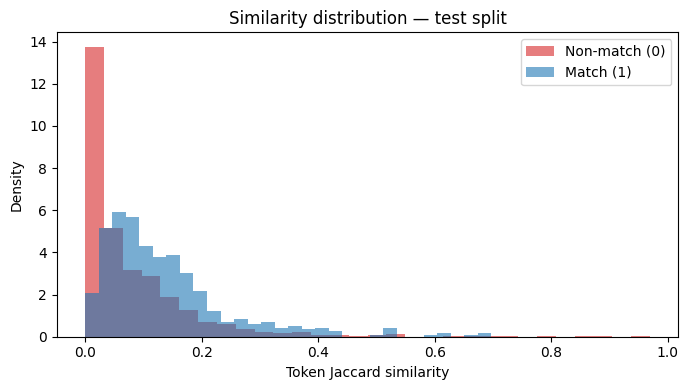

In [30]:
test_pairs = load_pairs(test_file)
n_test = len(test_pairs)
n_test_pos = sum(l for _, _, l in test_pairs)
n_test_neg = n_test - n_test_pos

print(f"Test split: {SPLIT}.txt")
print(f"Total pairs   : {n_test:,}")
print(f"Matches (pos) : {n_test_pos:,}  ({100*n_test_pos/n_test:.1f}%)")
print(f"Non-matches   : {n_test_neg:,}  ({100*n_test_neg/n_test:.1f}%)")

test_sims = [(pair_sim(l, r), label) for l, r, label in test_pairs]
test_sims_pos = [s for s, lab in test_sims if lab == 1]
test_sims_neg = [s for s, lab in test_sims if lab == 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test_sims_neg, bins=30, alpha=0.6, color="#d62728", label="Non-match (0)", density=True)
ax.hist(test_sims_pos, bins=30, alpha=0.6, color="#1f77b4", label="Match (1)", density=True)
ax.set_xlabel("Token Jaccard similarity")
ax.set_ylabel("Density")
ax.set_title(f"Similarity distribution — {SPLIT} split")
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# Corner case % in test set
test_hard_pos = sum(1 for (_, _, lab), (sim, _) in zip(test_pairs, test_sims) if lab == 1 and sim < 0.3)
test_hard_neg = sum(1 for (_, _, lab), (sim, _) in zip(test_pairs, test_sims) if lab == 0 and sim > 0.4)
n_test_cc = test_hard_pos + test_hard_neg

print("Corner cases in test split (similarity-based):")
print(f"  Hard positives (label=1, Jaccard<0.3): {test_hard_pos:,}  ({100*test_hard_pos/n_test:.1f}%)")
print(f"  Hard negatives (label=0, Jaccard>0.4): {test_hard_neg:,}  ({100*test_hard_neg/n_test:.1f}%)")
print(f"  Total                                : {n_test_cc:,}  ({100*n_test_cc/n_test:.1f}%)")

Corner cases in test split (similarity-based):
  Hard positives (label=1, Jaccard<0.3): 455  (10.1%)
  Hard negatives (label=0, Jaccard>0.4): 71  (1.6%)
  Total                                : 526  (11.7%)


---
## Section 4 — Error Analysis

Requires `_preds.jsonl` — run `evaluate.py --save_preds` first if the file is missing.

In [32]:
if not preds_file.exists():
    print(f"[skipped] {preds_file} not found.")
    print(f"Run: python src/baseline/evaluate.py --dataset {DATASET} --run {RUN} --split {SPLIT} --save_preds")
else:
    preds_data = []
    with open(preds_file) as f:
        for line in f:
            preds_data.append(json.loads(line))

    for p in preds_data:
        p["sim"] = pair_sim(p["left"], p["right"])

    fps = [p for p in preds_data if p["pred_label"] == 1 and p["true_label"] == 0]
    fns = [p for p in preds_data if p["pred_label"] == 0 and p["true_label"] == 1]

    print(f"Total predictions : {len(preds_data):,}")
    print(f"False positives   : {len(fps):,}")
    print(f"False negatives   : {len(fns):,}")

Total predictions : 4,500
False positives   : 189
False negatives   : 148


In [33]:
if preds_file.exists():
    # 4a — Top FPs (highest model confidence)
    fps_sorted = sorted(fps, key=lambda p: p["score"], reverse=True)[:10]

    rows = []
    for p in fps_sorted:
        rows.append({
            "Left (value text)": truncate(p["left"]),
            "Right (value text)": truncate(p["right"]),
            "Score": f"{p['score']:.3f}",
            "Jaccard": f"{p['sim']:.3f}",
        })

    print("Top 10 False Positives (predicted=match, true=non-match):")
    display(pd.DataFrame(rows))

Top 10 False Positives (predicted=match, true=non-match):


,Left (value text),Right (value text),Score,Jaccard
0,HYDRO FLASK HYDRO FLASK HYDRO FLASK 32OZ WIDE...,Hydro Flask - 32 oz Wide Mouth Big enough for...,1.000,0.345
1,D-link DGS-1210-24P best price 24-Port Gigabi...,D-Link DGS-1210-24 The DGS-1210-24 is part of...,1.000,0.024
2,SANDISK EXTREME PRO SDHC 32GB 300MB/s UHS-II ...,Sandisk SanDisk Extreme PRO® SD™ UHS-II Card ...,1.000,0.121
3,ZEBRA 800033-801 BLACK RIBBON (1000 PRINTS) T...,Zebra 800015-101 Black Monochrome Ribbon - K -...,1.000,0.147
4,SANDISK EXTREME PRO SDHC 32GB 300MB/s UHS-II ...,SanDisk SanDisk Extreme PRO UHS-II SD Card Re...,1.000,0.149
5,"TP-Link Omada EAP225 Outdoor, Access Point ...",TP-Link Omada EAP225-Outdoor The Omada EAP225...,1.000,0.010
6,D-Link DGS-1210-24 The DGS-1210-24 is part of...,D-link Switch DGS-1210-24P 24 porturi D-Link...,1.000,0.013
7,HyperX FURY Blue 8GB (2x4GB) 1600MHz DDR3 Memo...,"Kingston HyperX FURY schwarz DIMM Kit 8GB, DDR...",1.000,0.118
8,Verižnik SH Dura Ace CS-9100 11P 11-25 Shiman...,Shimano Shimano Dura-Ace CS-R9100 11 Speed Ca...,1.000,0.106
9,Jabra BIZ 2300 USB MS Duo - headset Your cont...,Jabra Biz 2300 USB Duo Headset The Jabra Biz ...,1.000,0.143


In [34]:
if preds_file.exists():
    # 4b — Top FNs (lowest model confidence on true matches)
    fns_sorted = sorted(fns, key=lambda p: p["score"])[:10]

    rows = []
    for p in fns_sorted:
        rows.append({
            "Left (value text)": truncate(p["left"]),
            "Right (value text)": truncate(p["right"]),
            "Score": f"{p['score']:.3f}",
            "Jaccard": f"{p['sim']:.3f}",
        })

    print("Top 10 False Negatives (predicted=non-match, true=match):")
    display(pd.DataFrame(rows))

Top 10 False Negatives (predicted=non-match, true=match):


,Left (value text),Right (value text),Score,Jaccard
0,Fujifilm 23mm f2 R WR XF Lens - Black The Fuj...,FUJIFILM Fujinon XF 27mm f/2.8 Aspherical Lens...,0.000,0.140
1,Extreme Sdxc 128Gb 150Mb/S C10 U3 SanDisk 128...,SANDISK 128GB SDXV5 EXTREME SDXC MEMORY CARD (...,0.000,0.073
2,DLINK - DGS-1210-28P - 28 Port Gigabit Smart M...,D-LINK/NET/24X1GB POE SWITCH /+ 4 SFP/L2/RM D...,0.000,0.091
3,Elixir Elixir Nanoweb Coated Acoustic Guitar ...,Elixir 16002 Acoustic Strings Phosphor Bronze ...,0.000,0.168
4,Intel Intel Core i7-9700F processor 3 GHz Box...,Intel Core i7 9700f Coffee Lake Refresh Eight ...,0.000,0.027
5,Epson Epson C13T636800 Matte Black 700ml C13...,Epson Epson Tinte T6368 Matt Black UltraChrom...,0.000,0.118
6,Logitech Logitech BRIO webcam 4096 x 2160 pix...,Logitech Logitech Brio Ultra HD Pro 4K with H...,0.000,0.073
7,"UVC-G3-FLEX-3Ubiquiti UniFi Video Camera, G3, ...",Ubiquiti Ubiquiti UniFi 2MP 1080p Wide-angle ...,0.000,0.100
8,Hydro Flask Hydro Flask Wide Mouth Drink Bott...,32 Oz Wide Mouth With Flex Cap W32BTS650 32 O...,0.000,0.122
9,Corsair case Crystal Series 570X RGBTempered G...,Corsair Crystal 570X RGB Mid-Tower Black ATX C...,0.000,0.089


In [35]:
if preds_file.exists():
    # 4c — Error classification summary
    all_errors = fps + fns
    error_classes = [classify_error(p["left"], p["right"], p["true_label"], p["pred_label"], p["sim"])
                     for p in all_errors]
    counts = Counter(error_classes)
    n_errors = len(all_errors)

    print("Error classification summary:")
    print(f"{'Error class':<28} {'Count':>6}  {'%':>6}  Example")
    print("-" * 100)
    for cls in ["high-sim non-match", "low-sim match", "noisy/incomplete text", "ambiguous variant"]:
        n = counts.get(cls, 0)
        pct = 100 * n / n_errors if n_errors else 0
        example_p = next((p for p in all_errors if classify_error(
            p["left"], p["right"], p["true_label"], p["pred_label"], p["sim"]) == cls), None)
        ex = truncate(example_p["left"], 60) if example_p else "—"
        print(f"{cls:<28} {n:>6}  {pct:>5.1f}%  {ex}")

Error classification summary:
Error class                   Count       %  Example
----------------------------------------------------------------------------------------------------
high-sim non-match                5    1.5%  RAM® Double Socket Arm C Ball B Length  C Size 1.5" Rubber B…
low-sim match                   122   36.2%  T7 Portable SSD - 2TB Indigo Blue  Light and pocket-sized, t…
noisy/incomplete text             2    0.6%  SAMYANG24mm/1.4 ED AS UMC Nikon
ambiguous variant               208   61.7%  Crucial 4GB 1600MHz DDR3L SO-DIMM Laptop Memory SR  Go Faste…


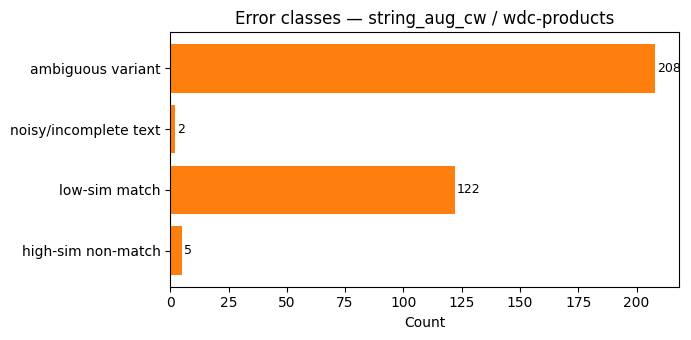

In [36]:
if preds_file.exists():
    # Error class bar chart
    class_order = ["high-sim non-match", "low-sim match", "noisy/incomplete text", "ambiguous variant"]
    class_counts = [counts.get(c, 0) for c in class_order]

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.barh(class_order, class_counts, color="#ff7f0e")
    for bar, val in zip(bars, class_counts):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=9)
    ax.set_xlabel("Count")
    ax.set_title(f"Error classes — {RUN} / {DATASET}")
    plt.tight_layout()
    plt.show()